In [1]:
import matplotlib.pyplot as plt
from cryosim import rotations
import torch
from cryosim.cryosparc_utils import create_particle_starfile
from cryosim.fft_tools import fft2
from cryosim.image_tools import normalize_particles
from cryosim.imagegenerator import ImageGenerator
from cryosim.plotting_tools import *
from cryosim.pdbtools import PDB
from cryosim.potential import PotentialBuilder
from rich.progress import track

%load_ext autoreload
%autoreload 2

## Create 3D scattering potential

In [2]:
# fetch pdb file
pdb_code = "7a4m"
assembly = True # True: fetches assembly. False: fetches subunit. int: fetches specific assembly #int
pdb = PDB(pdb_code, assembly=True, savefolder="../pdb-data/")

Assemblies available: 1
7a4m: Fetching default Biological Assembly 1
File already exists: ../pdb-data/7a4m-assembly1.cif, skip fetching.


Output()

In [3]:
# Samples 3D scattering potential onto specified grid
n = 256  # number of pixels per axis
dx = 1  # angstrom, pixel size.
device = 'cpu'
pb = PotentialBuilder(n, dx, pdb.atomic_numbers).to(device)

In [4]:
with torch.no_grad():
    V = pb(pdb.coordinates).clone()

Output()

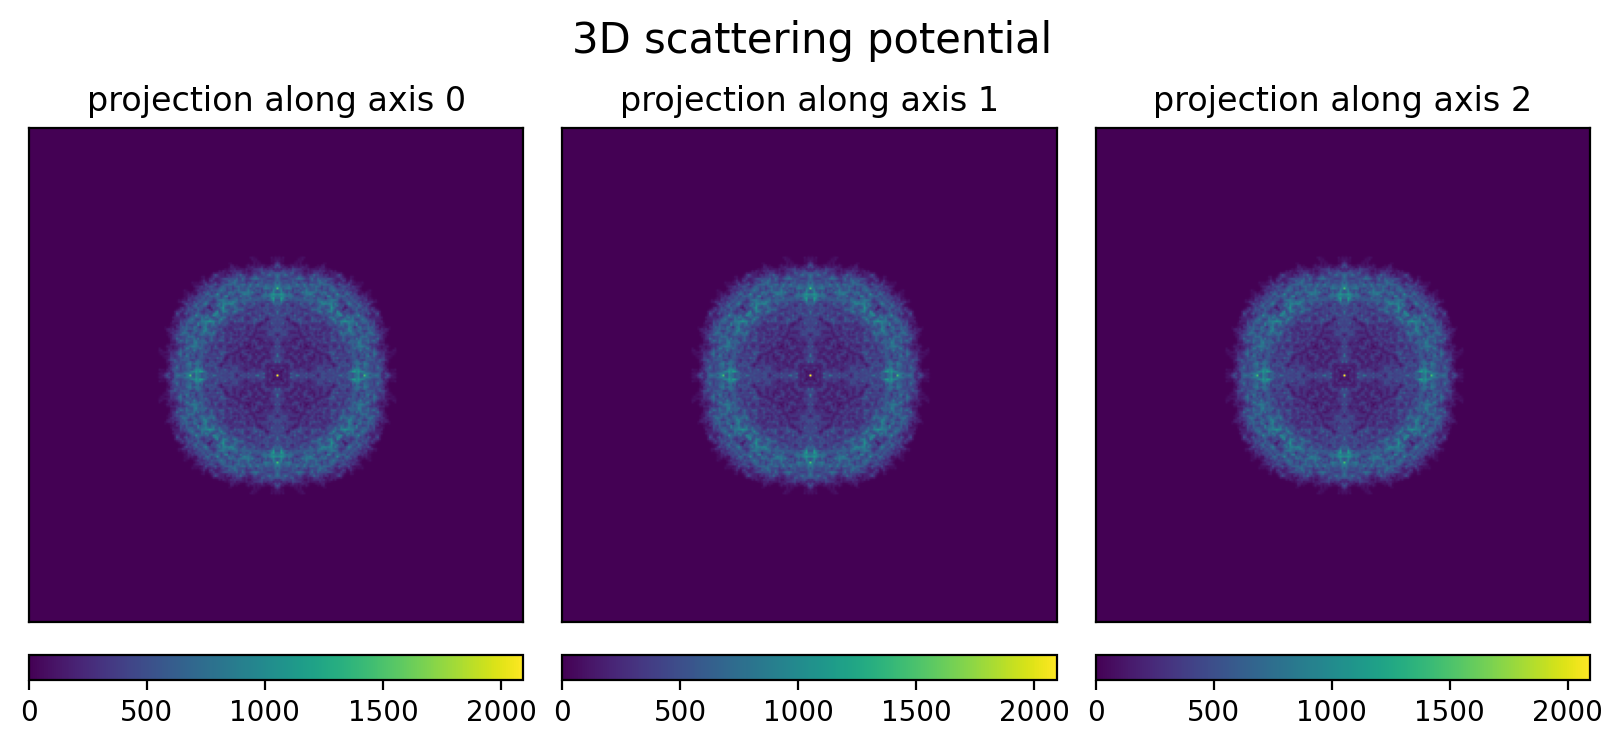

In [5]:
plot3d(V, title="3D scattering potential")

## Generate dataset
Here, you can choose to either use random or in-plane rotations, and random or fixed defocus values (comment/uncomment respectively).

In [6]:
energy = 300  # keV
dose_per_angstrom = 20  # e-/A^2
Cs = 2e7  # angstrom. Sherical aberration, typical values are 1-3 mm.
alpha = 0.1
n_particles = 2

In [7]:
# random quaternions
quaternions = torch.tensor([[0., 0., 0., 1.], [0., 0., 0., 1.]])
quaternions.shape

torch.Size([2, 4])

In [8]:
# random defocus
defocus_min = 5000  # angstrom
defocus_max = 15000  # angstrom
defocus_A = torch.rand(n_particles) * (defocus_max - defocus_min) + defocus_min


# Can include 'cs', 'dfu', 'dfv', 'dfang', 'tiltx', 'tilty', 'phaseshift', 'trefoil1, 'trefoil2'
ctf_params = {
    "cs": torch.tensor([Cs]*n_particles),
    "dfu": defocus_A,
}

In [9]:
# random shift. set to 0 for no shifts
shift = 2  # A
rlnOriginXAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
rlnOriginYAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
translations = torch.stack([rlnOriginXAngst, rlnOriginYAngst], dim=-1)
translations.shape

torch.Size([2, 2])

In [10]:
device = "cuda:0"  # choose cpu if you run out of cuda memory.

## Vary ice thickness

In [11]:
# Use multislice, holography, poisson and random_choice to obtain close to experimental conditions.
scattering_model = "multislice"  # 'multislice', 'firstborn', 'projection', 'ctf'
aberration_model = "holography"  # 'holography' or 'ctf'

noise_model = "poisson"  # 'poisson' or None
# noise_model = None

ice_model = "iterative"  # 'randomchoice' for fast & inaccurate, 'iterative' for slow & accurate, or None
# ice_model = None

# crowd_min_distance = pdb.max_diameter # angstroms, set to None for no crowding
crowd_min_distance = None

crowd_max_distance_z = None # if None, defaults to ice_thickness which would result in too many particles above each other.

# pad_fft = False # True to avoid edge artifacts when if crowd_min_distance is not None
pad_fft = True

In [12]:
ice_thickness = [256, 512, 1024, 2048]  # angstroms, set to 0 for minimum ice thickness = particle box size
results = []
for it in track(ice_thickness):
    model = ImageGenerator(
        V,
        dx,
        quaternions,
        translations,
        ctf_params,
        energy,
        dose_per_angstrom,
        ice_model=ice_model,
        ice_thickness=it,
        scattering_model=scattering_model,
        aberration_model=aberration_model,
        noise_model=noise_model,
        klim=None,
        flip_curvature=False,
        alpha=alpha,
        crowd_min_distance=crowd_min_distance,
        crowd_max_distance_z=crowd_max_distance_z,
        pad_fft=pad_fft,
    ).to(device)
    image = model(torch.tensor([0,1]))
    results.append(torch.squeeze(image).detach().cpu())

results = torch.stack(results)

Output()

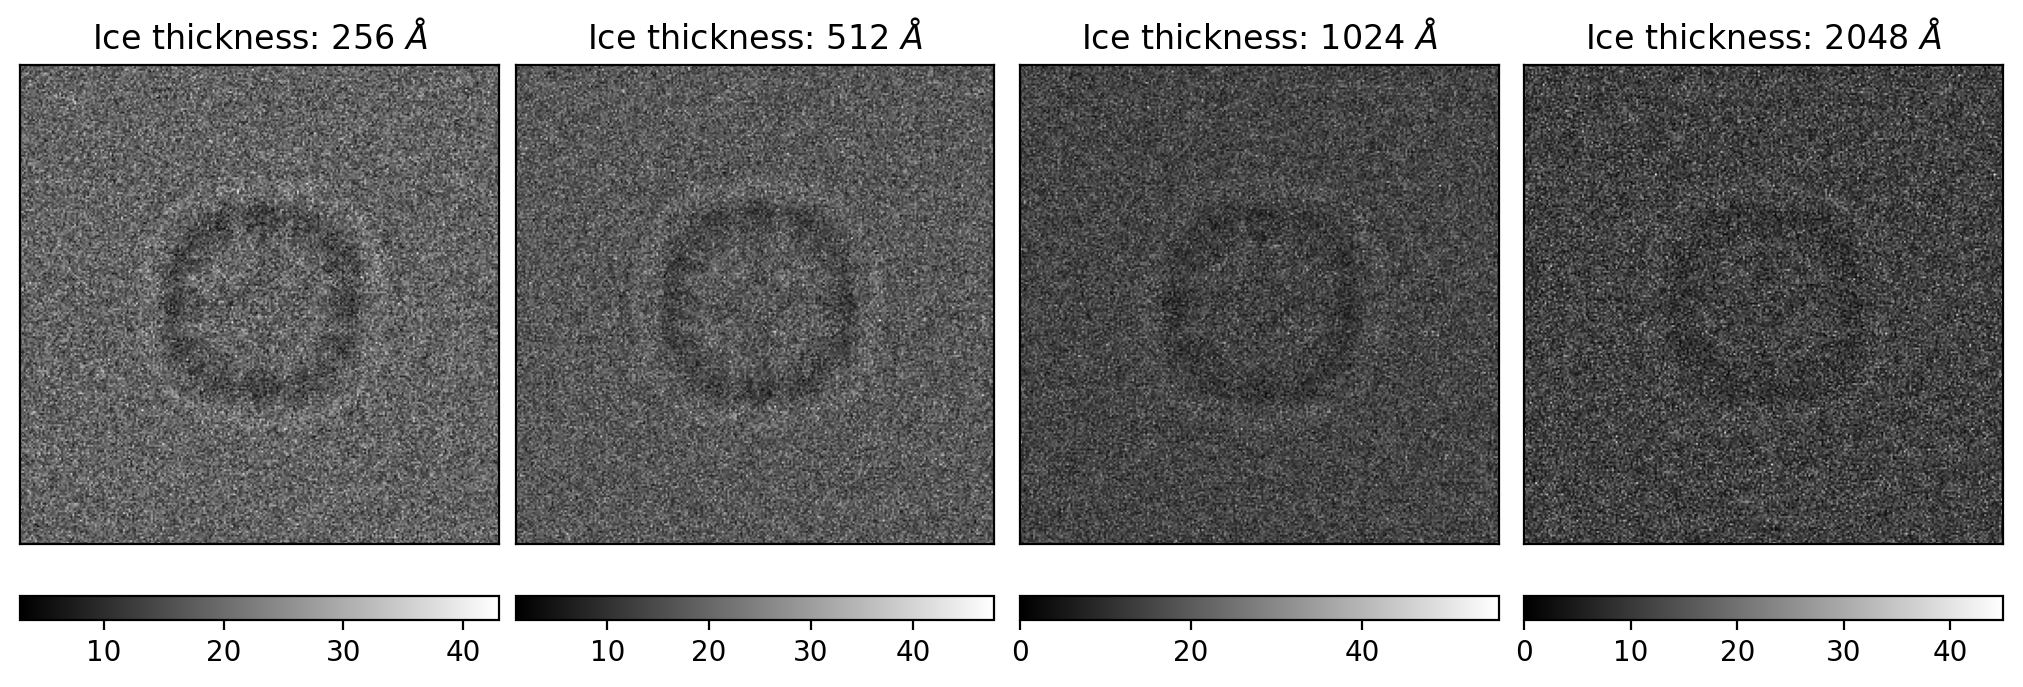

In [13]:
fig, axes = plt.subplots(1, 4, dpi=200, constrained_layout=True, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(results[i][0], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Ice thickness: {ice_thickness[i]} $\AA$")
    fig.colorbar(im, ax=ax, location="bottom")
plt.show()

## Artificially reduce scattering potential

In [14]:
# Use multislice, holography, poisson and random_choice to obtain close to experimental conditions.
scattering_model = "multislice"  # 'multislice', 'firstborn', 'projection', 'ctf'
aberration_model = "holography"  # 'holography' or 'ctf'

noise_model = "poisson"  # 'poisson' or None
# noise_model = None

ice_model = "iterative"  # 'randomchoice' for fast & inaccurate, 'iterative' for slow & accurate, or None
# ice_model = None

# crowd_min_distance = pdb.max_diameter # angstroms, set to None for no crowding
crowd_min_distance = None

crowd_max_distance_z = None # if None, defaults to ice_thickness which would result in too many particles above each other.

# pad_fft = False # True to avoid edge artifacts when if crowd_min_distance is not None
pad_fft = True

In [15]:
ice_thickness = 0  # angstroms, set to 0 for minimum ice thickness = particle box size
scaling_factor = [1, 0.75, 0.5, 0.25, 0.1]
results = []
for sf in track(scaling_factor):
    model = ImageGenerator(
        V * sf,
        dx,
        quaternions,
        translations,
        ctf_params,
        energy,
        dose_per_angstrom,
        ice_model=ice_model,
        ice_thickness=ice_thickness,
        scattering_model=scattering_model,
        aberration_model=aberration_model,
        noise_model=noise_model,
        klim=None,
        flip_curvature=False,
        alpha=alpha,
        crowd_min_distance=crowd_min_distance,
        crowd_max_distance_z=crowd_max_distance_z,
        pad_fft=pad_fft,
    ).to(device)
    image = model(torch.tensor([0,1]))
    results.append(torch.squeeze(image).detach().cpu())

results = torch.stack(results)

Output()

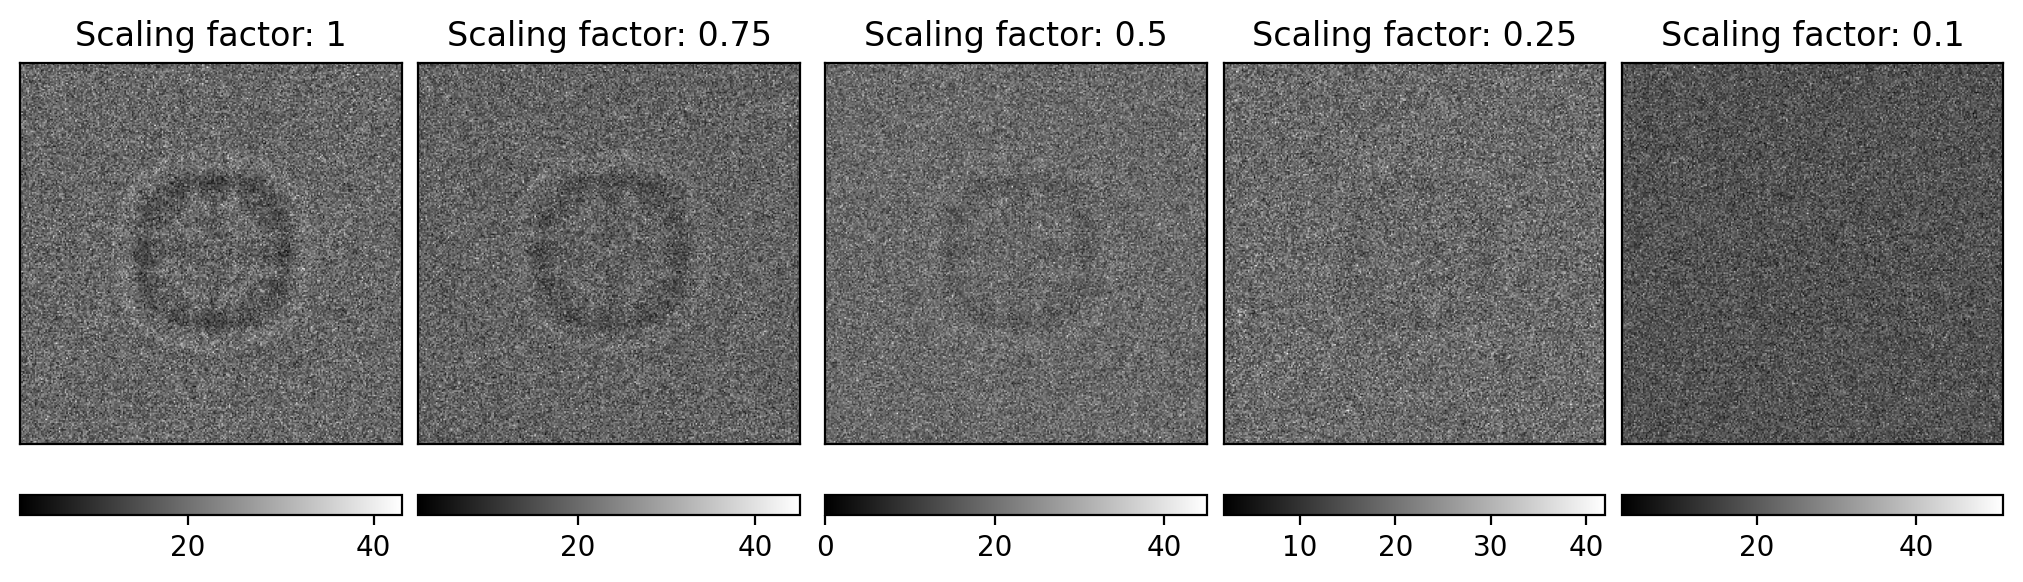

In [16]:
fig, axes = plt.subplots(1, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(results[i][0], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Scaling factor: {scaling_factor[i]}")
    fig.colorbar(im, ax=ax, location="bottom")
plt.show()